In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (545, 13)

Column Names:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str

In [5]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [6]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Duplicate Rows: 0


In [7]:
df.head()

df.shape

df.info()

df.isnull().sum()

df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB


np.int64(0)

## Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution of house prices, examine relationships between numerical features, identify potential outliers, and analyze how categorical housing features influence property prices.

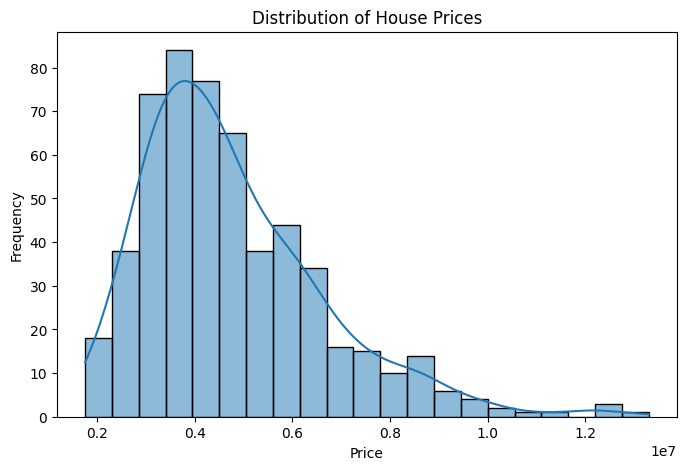

In [8]:
plt.figure(figsize=(8, 5))

sns.histplot(df["price"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

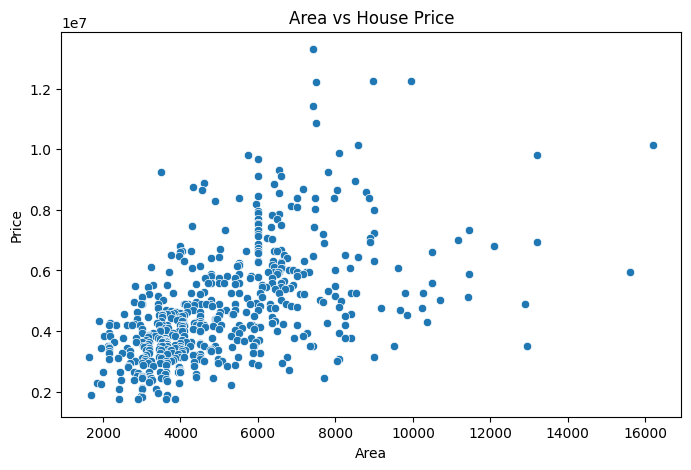

In [9]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x="area", y="price", data=df)

plt.title("Area vs House Price")
plt.xlabel("Area")
plt.ylabel("Price")

plt.show()

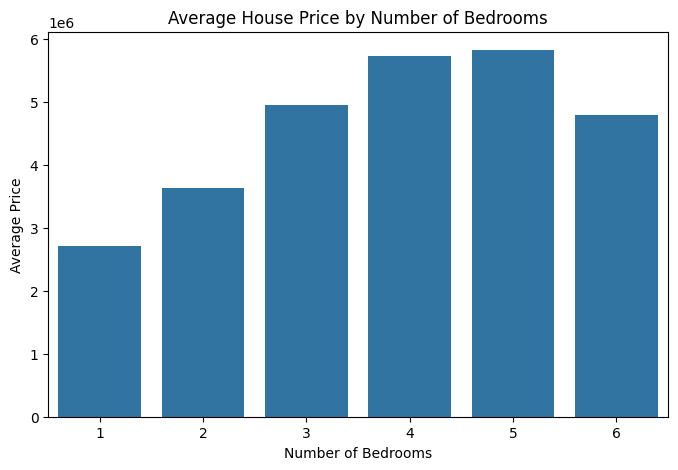

In [10]:
bedroom_price = df.groupby("bedrooms")["price"].mean().reset_index()

plt.figure(figsize=(8, 5))

sns.barplot(x="bedrooms", y="price", data=bedroom_price)

plt.title("Average House Price by Number of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Average Price")

plt.show()

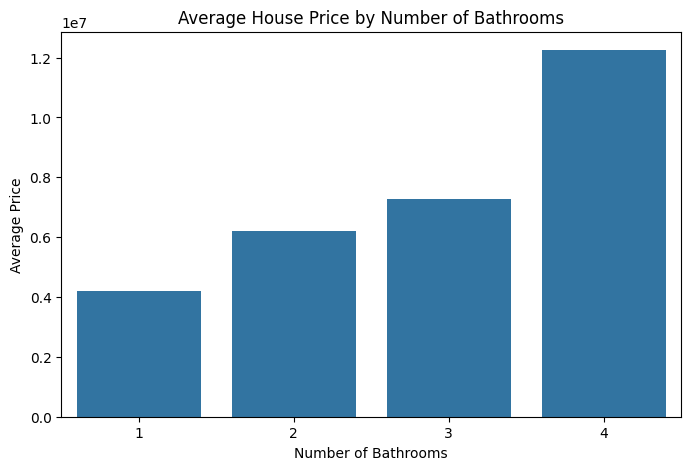

In [11]:
bathroom_price = df.groupby("bathrooms")["price"].mean().reset_index()

plt.figure(figsize=(8, 5))

sns.barplot(x="bathrooms", y="price", data=bathroom_price)

plt.title("Average House Price by Number of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Average Price")

plt.show()

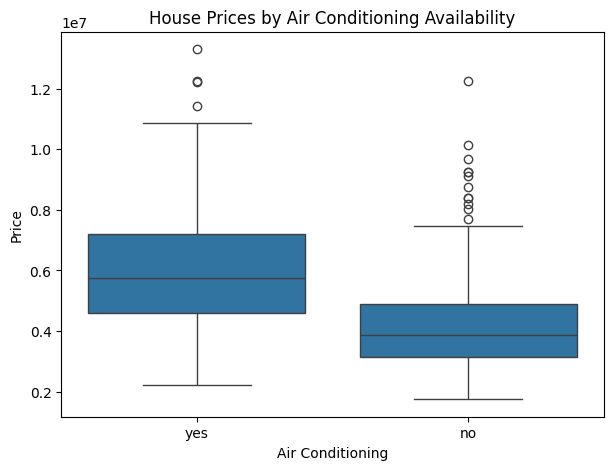

In [12]:
plt.figure(figsize=(7, 5))

sns.boxplot(x="airconditioning", y="price", data=df)

plt.title("House Prices by Air Conditioning Availability")
plt.xlabel("Air Conditioning")
plt.ylabel("Price")

plt.show()

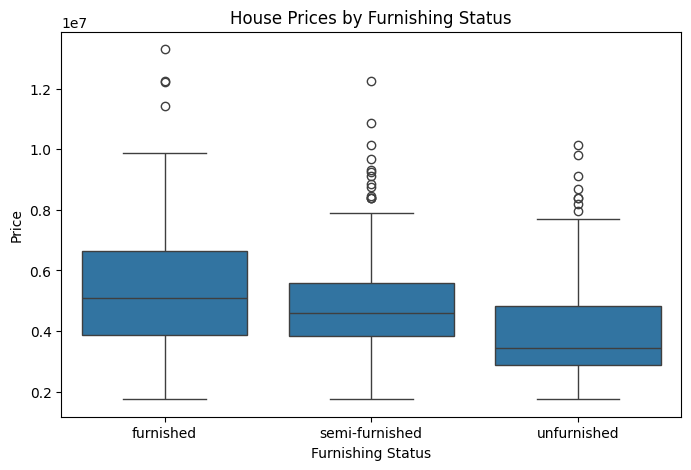

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="furnishingstatus", y="price", data=df)

plt.title("House Prices by Furnishing Status")
plt.xlabel("Furnishing Status")
plt.ylabel("Price")

plt.show()

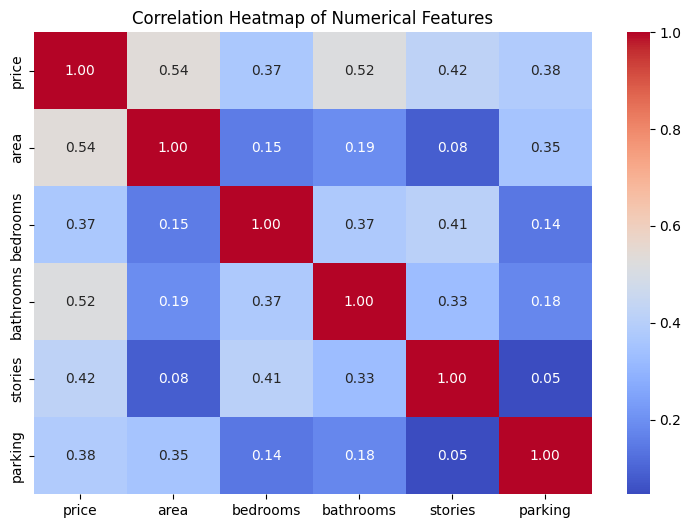

In [14]:
numerical_columns = df.select_dtypes(include=np.number)

plt.figure(figsize=(9, 6))

sns.heatmap(
    numerical_columns.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

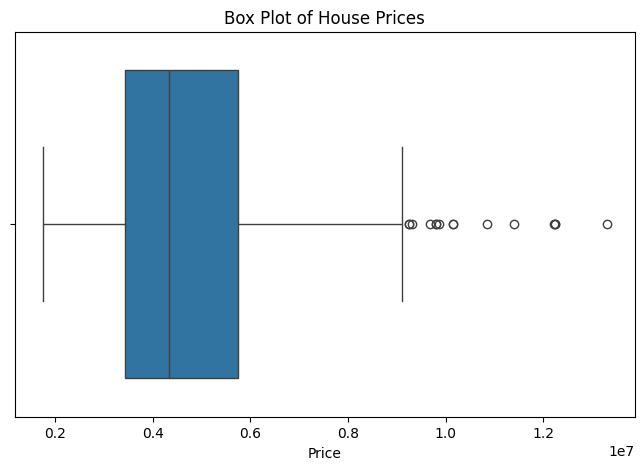

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["price"])

plt.title("Box Plot of House Prices")
plt.xlabel("Price")

plt.show()

## EDA Observations

- The house price distribution contains several high-priced properties, indicating that the target variable is right-skewed.

- The scatter plot between area and price shows a moderate positive relationship. In general, larger houses tend to have higher prices, although the variation in prices increases for larger properties.

- The correlation heatmap shows that `area` has the highest correlation with house price (0.54), followed by `bathrooms` (0.52), `stories` (0.42), `parking` (0.38), and `bedrooms` (0.37).

- Furnished houses generally have higher median prices than semi-furnished and unfurnished houses. However, all furnishing categories contain some high-priced properties and potential outliers.

- The box plot of house prices shows several observations above the upper whisker. These properties are potential outliers representing unusually expensive houses.

- The potential outliers are retained because they may represent genuine high-value properties, and removing them without additional domain information could result in loss of useful information.

Overall, the exploratory analysis indicates that both numerical features such as area and bathrooms and categorical housing amenities may contribute to predicting house prices.

## Data Preprocessing

The dataset contains both numerical and categorical features. The categorical variables are converted into numerical form using one-hot encoding so that they can be used by machine learning algorithms. The target variable `price` is separated from the input features before splitting the dataset into training and testing sets.

In [16]:
X = df.drop("price", axis=1)
y = df["price"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (545, 12)
Target Shape: (545,)


In [17]:
X = df.drop("price", axis=1)
y = df["price"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (545, 12)
Target Shape: (545,)


In [18]:
categorical_columns = X.select_dtypes(include="object").columns

print("Categorical Columns:")
print(categorical_columns.tolist())

Categorical Columns:
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [19]:
X = pd.get_dummies(X, columns=categorical_columns, drop_first=True)

X.head()

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [20]:
print("Shape After Encoding:", X.shape)

print("\nFeatures After Encoding:")
print(X.columns.tolist())

Shape After Encoding: (545, 13)

Features After Encoding:
['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (436, 13)
Testing Features: (109, 13)
Training Target: (436,)
Testing Target: (109,)


## Model 1: Linear Regression

Linear Regression is used as the baseline regression model for predicting house prices. The model learns the linear relationship between the input housing features and the target variable, house price.

In [22]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
y_pred_lr = linear_model.predict(X_test)

y_pred_lr[:5]

array([5164653.90033967, 7224722.29802167, 3109863.24240338,
       4612075.3272256 , 3294646.25725956])

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("--------------------------------")
print(f"MAE  : {mae_lr:.2f}")
print(f"MSE  : {mse_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R²   : {r2_lr:.4f}")

Linear Regression Performance
--------------------------------
MAE  : 970043.40
MSE  : 1754318687330.66
RMSE : 1324506.96
R²   : 0.6529


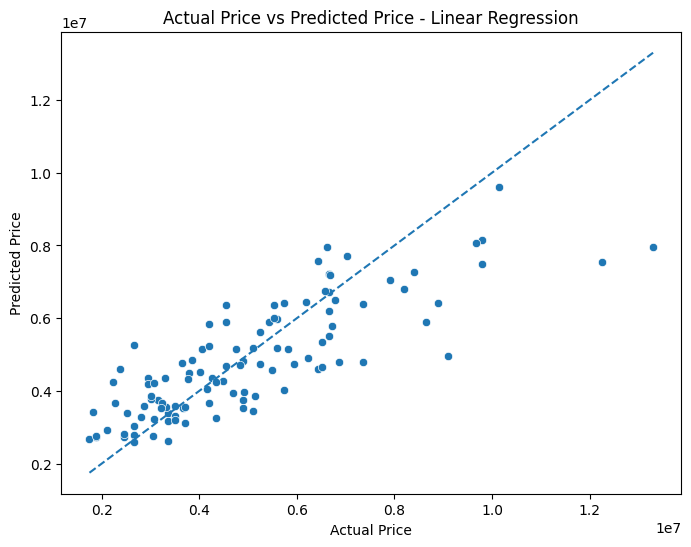

In [25]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test, y=y_pred_lr)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Actual Price vs Predicted Price - Linear Regression")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.show()

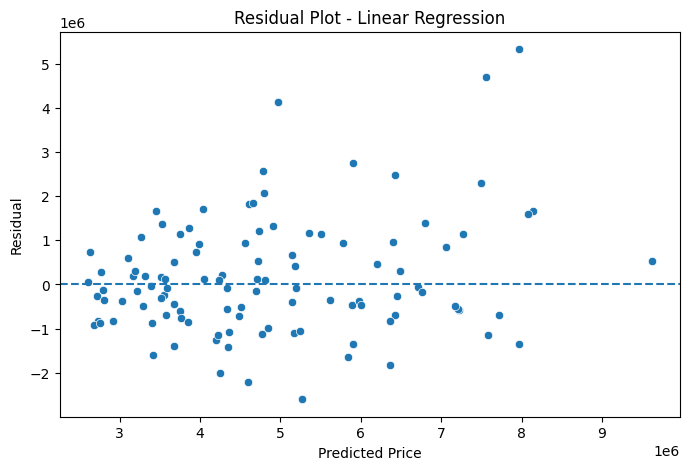

In [26]:
residuals_lr = y_test - y_pred_lr

plt.figure(figsize=(8, 5))

sns.scatterplot(x=y_pred_lr, y=residuals_lr)

plt.axhline(y=0, linestyle="--")

plt.title("Residual Plot - Linear Regression")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.show()

### Linear Regression Results

The Linear Regression model achieved an R² score of approximately 0.65, indicating that the model explains about 65.29% of the variation in house prices.

The Mean Absolute Error (MAE) is approximately 970,043, which means that the model's predictions differ from the actual house prices by about 970,043 price units on average.

The Root Mean Squared Error (RMSE) is approximately 1,324,507. Since RMSE penalizes large prediction errors more strongly than MAE, its higher value suggests that some houses have relatively large prediction errors.

Overall, Linear Regression provides a reasonable baseline model, but additional machine learning models should be evaluated to determine whether prediction performance can be improved.

In [27]:
from sklearn.tree import DecisionTreeRegressor

decision_tree_model = DecisionTreeRegressor(random_state=42)

decision_tree_model.fit(X_train, y_train)

y_pred_dt = decision_tree_model.predict(X_test)

In [28]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Performance")
print("--------------------------------")
print(f"MAE  : {mae_dt:.2f}")
print(f"MSE  : {mse_dt:.2f}")
print(f"RMSE : {rmse_dt:.2f}")
print(f"R²   : {r2_dt:.4f}")

Decision Tree Performance
--------------------------------
MAE  : 1195266.06
MSE  : 2642802637614.68
RMSE : 1625669.90
R²   : 0.4771


In [29]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

In [30]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("--------------------------------")
print(f"MAE  : {mae_rf:.2f}")
print(f"MSE  : {mse_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"R²   : {r2_rf:.4f}")

Random Forest Performance
--------------------------------
MAE  : 1021546.04
MSE  : 1961585044320.34
RMSE : 1400565.97
R²   : 0.6119


In [31]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE": [
        mae_lr,
        mae_dt,
        mae_rf
    ],

    "RMSE": [
        rmse_lr,
        rmse_dt,
        rmse_rf
    ],

    "R² Score": [
        r2_lr,
        r2_dt,
        r2_rf
    ]
})

model_results

,Model,MAE,RMSE,R² Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Decision Tree,1.195266e+06,1.625670e+06,0.477146
2,Random Forest,1.021546e+06,1.400566e+06,0.611919


In [32]:
model_results.sort_values(
    by="R² Score",
    ascending=False
).reset_index(drop=True)

,Model,MAE,RMSE,R² Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919
2,Decision Tree,1.195266e+06,1.625670e+06,0.477146


### Model Comparison

Three regression algorithms were evaluated for house price prediction: Linear Regression, Decision Tree Regressor, and Random Forest Regressor.

Linear Regression achieved the best performance with an R² score of approximately 0.653 and the lowest MAE and RMSE values among the evaluated models.

Random Forest achieved an R² score of approximately 0.612. Although Random Forest can capture complex non-linear relationships, it did not outperform Linear Regression on this dataset.

Decision Tree achieved the lowest R² score of approximately 0.477 and the highest prediction errors, indicating weaker generalization to unseen data.

Based on the current test results, Linear Regression is the best-performing model. However, training and testing performance should be compared before selecting the final model to identify possible overfitting.

In [34]:
models = {
    "Linear Regression": linear_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

for name, model in models.items():

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    print(name)
    print(f"Training R² : {train_score:.4f}")
    print(f"Testing R²  : {test_score:.4f}")
    print("-" * 30)

Linear Regression
Training R² : 0.6859
Testing R²  : 0.6529
------------------------------
Decision Tree
Training R² : 0.9985
Testing R²  : 0.4771
------------------------------
Random Forest
Training R² : 0.9499
Testing R²  : 0.6119
------------------------------


### Overfitting Analysis

The training and testing R² scores were compared to evaluate the generalization performance of each model.

Linear Regression achieved a training R² score of 0.686 and a testing R² score of 0.653. The relatively small difference between these scores indicates that the model generalizes well to unseen data.

Decision Tree achieved a training R² score of approximately 0.999 but a testing R² score of only 0.477. This large performance gap indicates severe overfitting, where the model learns the training data very closely but performs poorly on unseen observations.

Random Forest achieved a training R² score of 0.950 and a testing R² score of 0.612. The difference between the training and testing scores indicates that the model also exhibits some overfitting, although it generalizes better than the individual Decision Tree.

Based on the training and testing performance, Linear Regression currently provides the best balance between predictive performance and generalization.

In [36]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, model in models.items():

    cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="r2"
    )

    print(name)
    print("Cross-Validation Scores:", np.round(cv_scores, 4))
    print(f"Mean CV R² : {cv_scores.mean():.4f}")
    print(f"Std CV R²  : {cv_scores.std():.4f}")
    print("-" * 50)

Linear Regression
Cross-Validation Scores: [0.6529 0.7121 0.4928 0.658  0.6464]
Mean CV R² : 0.6324
Std CV R²  : 0.0737
--------------------------------------------------
Decision Tree
Cross-Validation Scores: [ 0.4771  0.2677 -0.5947  0.3917  0.0254]
Mean CV R² : 0.1134
Std CV R²  : 0.3854
--------------------------------------------------
Random Forest
Cross-Validation Scores: [0.6147 0.6739 0.5151 0.656  0.6311]
Mean CV R² : 0.6182
Std CV R²  : 0.0554
--------------------------------------------------


### Cross-Validation Results

Five-fold shuffled cross-validation was performed to evaluate model performance across different subsets of the dataset.

Linear Regression achieved the highest mean cross-validation R² score of 0.632 with a standard deviation of 0.074, demonstrating the best overall generalization performance among the evaluated models.

Random Forest achieved a mean cross-validation R² score of 0.618 with a standard deviation of 0.055. Although its performance was relatively stable across folds, the model exhibited considerable overfitting based on the difference between its training and testing R² scores.

Decision Tree achieved a mean cross-validation R² score of only 0.113 with a high standard deviation of 0.385. The large variation in performance across folds and the presence of a negative R² score indicate poor and unstable generalization.

Based on the test-set performance, training-testing score comparison, and cross-validation results, Linear Regression currently provides the best predictive performance and generalization.

## Model 4: Ridge Regression

Ridge Regression extends Linear Regression by adding L2 regularization. Regularization penalizes large model coefficients and can improve generalization by reducing model complexity. GridSearchCV is used to select the optimal regularization strength using cross-validation.

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

ridge_params = {
    "ridge__alpha": [0.01, 0.1, 1, 10, 100, 1000]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_params,
    scoring="r2",
    cv=kf
)

ridge_grid.fit(X_train, y_train)

best_ridge_model = ridge_grid.best_estimator_

print("Best Alpha:", ridge_grid.best_params_["ridge__alpha"])
print("Best CV R²:", ridge_grid.best_score_)

Best Alpha: 10
Best CV R²: 0.6504365876502064


In [39]:
y_pred_ridge = best_ridge_model.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Performance")
print("--------------------------------")
print(f"MAE  : {mae_ridge:.2f}")
print(f"RMSE : {rmse_ridge:.2f}")
print(f"R²   : {r2_ridge:.4f}")

Ridge Regression Performance
--------------------------------
MAE  : 968319.37
RMSE : 1326679.13
R²   : 0.6518


In [40]:
ridge_cv_scores = cross_val_score(
    best_ridge_model,
    X,
    y,
    cv=kf,
    scoring="r2"
)

print("Ridge Cross-Validation Scores:", np.round(ridge_cv_scores, 4))
print(f"Mean CV R² : {ridge_cv_scores.mean():.4f}")
print(f"Std CV R²  : {ridge_cv_scores.std():.4f}")


Ridge Cross-Validation Scores: [0.6518 0.7116 0.497  0.6605 0.6476]
Mean CV R² : 0.6337
Std CV R²  : 0.0721


### Ridge Regression Results

Ridge Regression was evaluated to determine whether L2 regularization could improve the generalization performance of the Linear Regression model.

GridSearchCV selected an alpha value of 10 as the optimal regularization strength.

Ridge Regression achieved an R² score of approximately 0.652 on the test dataset, with an MAE of approximately 968,319 and an RMSE of approximately 1,326,679.

The performance of Ridge Regression was nearly identical to Linear Regression. Ridge achieved a slightly lower MAE, while Linear Regression achieved a slightly higher R² score and lower RMSE.

Therefore, the results indicate that regularization did not provide a significant improvement in predictive performance for this dataset.

In [41]:
final_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Ridge Regression"
    ],
    "MAE": [
        mae_lr,
        mae_dt,
        mae_rf,
        mae_ridge
    ],
    "RMSE": [
        rmse_lr,
        rmse_dt,
        rmse_rf,
        rmse_ridge
    ],
    "Test R²": [
        r2_lr,
        r2_dt,
        r2_rf,
        r2_ridge
    ],
    "Mean CV R²": [
        0.6324,
        0.1134,
        0.6182,
        ridge_cv_scores.mean()
    ]
})

final_results.sort_values(
    by="Test R²",
    ascending=False
).reset_index(drop=True)

,Model,MAE,RMSE,Test R²,Mean CV R²
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924,0.632400
1,Ridge Regression,9.683194e+05,1.326679e+06,0.651785,0.633699
2,Random Forest,1.021546e+06,1.400566e+06,0.611919,0.618200
3,Decision Tree,1.195266e+06,1.625670e+06,0.477146,0.113400


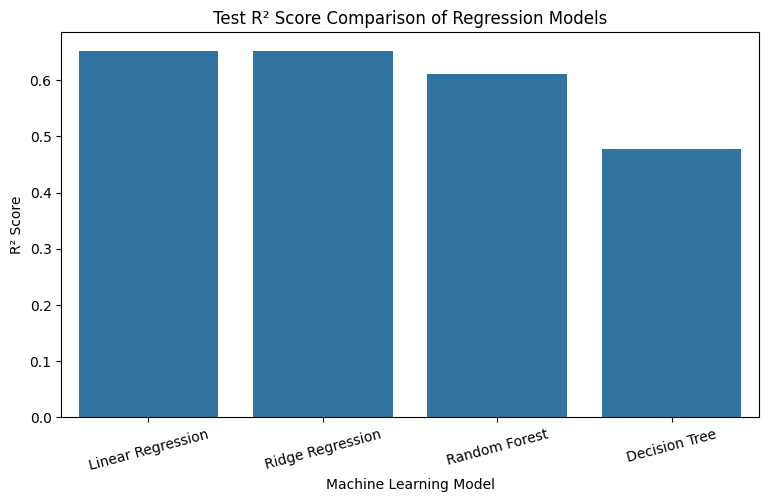

In [42]:
plt.figure(figsize=(9, 5))

results_sorted = final_results.sort_values(
    by="Test R²",
    ascending=False
)

sns.barplot(
    data=results_sorted,
    x="Model",
    y="Test R²"
)

plt.title("Test R² Score Comparison of Regression Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("R² Score")
plt.xticks(rotation=15)

plt.show()

In [43]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coefficients["Absolute Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient,Absolute Coefficient
2,bathrooms,1.094445e+06,1.094445e+06
9,airconditioning_yes,7.914267e+05,7.914267e+05
8,hotwaterheating_yes,6.846499e+05,6.846499e+05
10,prefarea_yes,6.298906e+05,6.298906e+05
12,furnishingstatus_unfurnished,-4.136451e+05,4.136451e+05
3,stories,4.074766e+05,4.074766e+05
7,basement_yes,3.902512e+05,3.902512e+05
5,mainroad_yes,3.679199e+05,3.679199e+05
6,guestroom_yes,2.316100e+05,2.316100e+05
4,parking,2.248419e+05,2.248419e+05


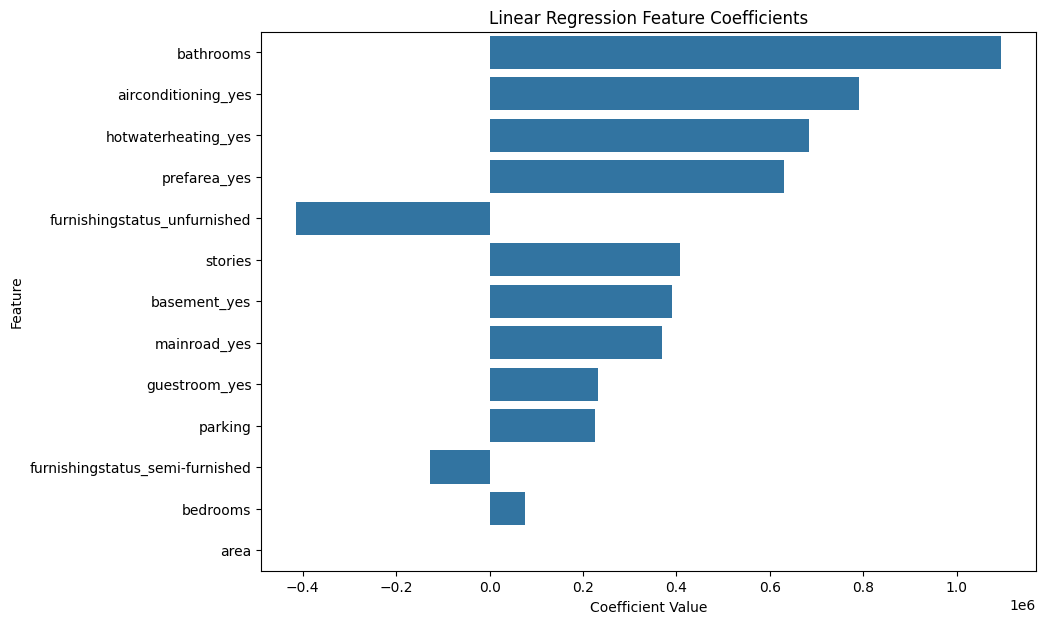

In [44]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Linear Regression Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.show()

### Linear Regression Coefficient Interpretation

The coefficients of the selected Linear Regression model were examined to understand the direction of the relationship between each feature and predicted house price.

A positive coefficient indicates that an increase in the corresponding feature is associated with an increase in predicted house price, while a negative coefficient indicates an association with a decrease in predicted house price, assuming the other features remain constant.

The categorical variables were one-hot encoded, so their coefficients represent differences relative to the category that was removed during encoding.

Since the numerical features are measured on different scales, the absolute magnitudes of the raw coefficients should not be directly interpreted as a ranking of overall feature importance.

In [45]:
prediction_results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred_lr
})

prediction_results.head(10)

,Actual Price,Predicted Price
316,4060000,5.164654e+06
77,6650000,7.224722e+06
360,3710000,3.109863e+06
90,6440000,4.612075e+06
493,2800000,3.294646e+06
209,4900000,3.532275e+06
176,5250000,5.611775e+06
249,4543000,6.368146e+06
516,2450000,2.722857e+06
426,3353000,2.629406e+06


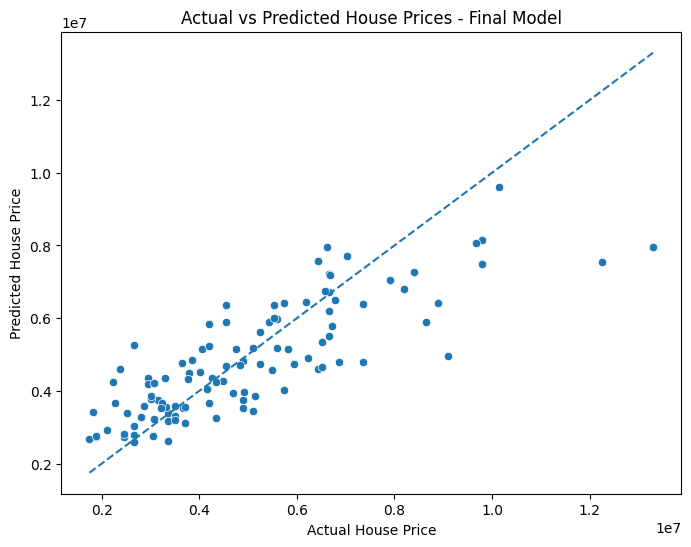

In [46]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_lr
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Actual vs Predicted House Prices - Final Model")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.show()

## Final Model Selection

Linear Regression was selected as the final model for this project.

The model achieved a test R² score of approximately 0.653, meaning that it explains about 65.3% of the variation in house prices in the test dataset.

Linear Regression achieved the lowest RMSE among the evaluated models and demonstrated a relatively small difference between its training and testing R² scores, indicating good generalization.

Ridge Regression achieved nearly identical performance and a slightly higher mean cross-validation score. However, the improvement was marginal, and Linear Regression provided slightly better performance on the held-out test dataset while remaining simpler and easier to interpret.

Decision Tree and Random Forest achieved substantially higher training scores but lower testing scores, indicating overfitting.

Therefore, Linear Regression was selected as the final model based on predictive performance, generalization, stability, and interpretability.

## Conclusion

This project developed and compared multiple machine learning regression models for predicting house prices using property characteristics and housing amenities.

Exploratory Data Analysis showed that house prices are influenced by both numerical characteristics, such as area and number of bathrooms, and categorical amenities, such as air conditioning, preferred area location, and furnishing status.

Categorical variables were transformed using one-hot encoding, and the dataset was divided into training and testing sets for model evaluation.

Four regression models were evaluated: Linear Regression, Decision Tree Regressor, Random Forest Regressor, and Ridge Regression.

Linear Regression achieved the best test performance with an R² score of approximately 0.653 and an RMSE of approximately 1.32 million price units. Cross-validation results also demonstrated relatively stable performance across different subsets of the dataset.

Decision Tree and Random Forest showed signs of overfitting, while Ridge Regression achieved performance nearly identical to Linear Regression.

Overall, Linear Regression provided the best balance between predictive performance, generalization, simplicity, and interpretability for this dataset.

Future improvements could include additional feature engineering, evaluation of target transformations, hyperparameter tuning of ensemble models, and testing gradient boosting algorithms on larger housing datasets.